### Introduction to FastScape software

We import the `basic_model` from fastscape that solves the Stream Power Law combined with hillslope diffusion and tectonic uplift:
$$\frac{\partial h}{\partial t}=U-K_f\Phi^mS^n+K_d\nabla^2 h$$
on a given rectangular domain $\mathcal{D}$ with boundary $\mathcal{C}$ with, by default, base level boundary conditions around the domain
$$h(x=\mathcal{C})=0$$
and an initial low relief random topography, $h_0$:
$$h(t=0)=h_0$$

It is based on a highly performant (i.e., $O(n)$) implicit finite difference scheme on a rectilinear 2D grid at a series of predefined time steps, $t_i$.


In [20]:
from fastscape.models import basic_model
import numpy as np
import matplotlib.pyplot as plt
%load_ext xsimlab.ipython

The xsimlab.ipython extension is already loaded. To reload it, use:
  %reload_ext xsimlab.ipython


We see that the model is made of many processes that correspond to the various terms in the equation, the boundary conditions and the initial condition

In [6]:
basic_model

<xsimlab.Model (16 processes, 12 inputs)>
grid
    shape           [in] ('shape_yx',) nb. of grid nodes in (y, x)
    length          [in] ('shape_yx',) total grid length in (y, x)
boundary
    status          [in] () or ('border',) node status at borders
fs_context
uplift
    rate            [in] () or ('y', 'x') uplift rate
tectonics
init_topography
    seed            [in] random seed
surf2erode
init_erosion
diffusion
    diffusivity     [in] () or ('y', 'x') diffusivity (transport co...
flow
drainage
spl
    k_coef          [in] () or ('y', 'x') bedrock channel incision ...
    area_exp        [in] drainage area exponent
    slope_exp       [in] slope exponent
    tol_rel         [in] relative tolerance (Gauss-Siedel convergence)
    tol_abs         [in] absolute tolerance (Gauss-Siedel convergence)
    max_iter        [in] max nb. of iterations (Gauss-Siedel conver...
erosion
vmotion
topography
terrain

In [12]:
basic_model.visualize

<bound method Model.visualize of <xsimlab.Model (16 processes, 12 inputs)>
grid
    shape           [in] ('shape_yx',) nb. of grid nodes in (y, x)
    length          [in] ('shape_yx',) total grid length in (y, x)
boundary
    status          [in] () or ('border',) node status at borders
fs_context
uplift
    rate            [in] () or ('y', 'x') uplift rate
tectonics
init_topography
    seed            [in] random seed
surf2erode
init_erosion
diffusion
    diffusivity     [in] () or ('y', 'x') diffusivity (transport co...
flow
drainage
spl
    k_coef          [in] () or ('y', 'x') bedrock channel incision ...
    area_exp        [in] drainage area exponent
    slope_exp       [in] slope exponent
    tol_rel         [in] relative tolerance (Gauss-Siedel convergence)
    tol_abs         [in] absolute tolerance (Gauss-Siedel convergence)
    max_iter        [in] max nb. of iterations (Gauss-Siedel conver...
erosion
vmotion
topography
terrain
>

We prepare an input dataset `ds_in` to provide the input parameters necessary for the model run

Note that we define a clock named `time`  that is used to determine the time steps at which the solution is computed

We also ask that the `topography__elevation` be saved

In this input dataset, we denote variables by the name of their `process` and the name of the `variable` in the process joined by a double underscore `__`


In [4]:
# %create_setup basic_model -v -d
import xsimlab as xs

tf = 5e6
nstep = 101
ds_in = xs.create_setup(
    model=basic_model,
    clocks={'time':np.linspace(0,tf,nstep)},
    input_vars={
        # nb. of grid nodes in (y, x)
        'grid__shape':[101,201],
        # total grid length in (y, x)
        'grid__length':[10e3,20e3],
        # node status at borders
        'boundary__status': 'fixed_value',
        # uplift rate
        'uplift__rate': 1e-3, 
        # bedrock channel incision coefficient
        'spl__k_coef': 1e-5,
        # drainage area exponent
        'spl__area_exp': 0.45,
        # slope exponent
        'spl__slope_exp': 1,
        # diffusivity (transport coefficient)
        'diffusion__diffusivity':0.1 ,
        # random seed
        'init_topography__seed': None,
    },
    output_vars={'topography__elevation':'time'}
)


We run the model to create an output dataset `ds_out`

In [7]:
with basic_model, xs.monitoring.ProgressBar():
    ds_out = ds_in.xsimlab.run()

             0% | initialize 

The output dataset is a copy of the input dataset enriched with the output variables, here, `topography__elevation`` which appears as a multi-dimensional array or DataArray in the output dataset

In [8]:
ds_out

<xarray.Dataset>
Dimensions:                 (border: 4, shape_yx: 2, time: 101, y: 101, x: 201)
Coordinates:
  * border                  (border) object 'left' 'right' 'top' 'bottom'
  * time                    (time) float64 0.0 5e+04 1e+05 ... 4.95e+06 5e+06
  * x                       (x) float64 0.0 100.0 200.0 ... 1.99e+04 2e+04
  * y                       (y) float64 0.0 100.0 200.0 ... 9.9e+03 1e+04
Dimensions without coordinates: shape_yx
Data variables: (12/13)
    boundary__status        <U11 'fixed_value'
    diffusion__diffusivity  float64 0.1
    grid__length            (shape_yx) float64 1e+04 2e+04
    grid__shape             (shape_yx) int64 101 201
    init_topography__seed   float64 nan
    spl__area_exp           float64 0.45
    ...                      ...
    spl__max_iter           int64 100
    spl__slope_exp          int64 1
    spl__tol_abs            float64 0.0001
    spl__tol_rel            float64 0.0001
    topography__elevation   (time, y, x) float64 0.2408 0.2841 ... 0.5986 0.3543
    uplift__rate            float64 0.001

We can perform operations on the output array, for example, plot them

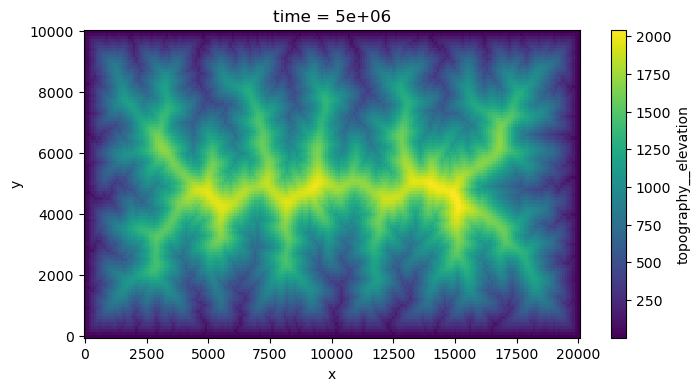

In [9]:
ds_out.topography__elevation.isel(time=-1).plot(size=4,aspect =2);

Or do statistics or integrated analysis on them.

Here we plot the evolutoin of mean topography with time to show that the system as reached steady state

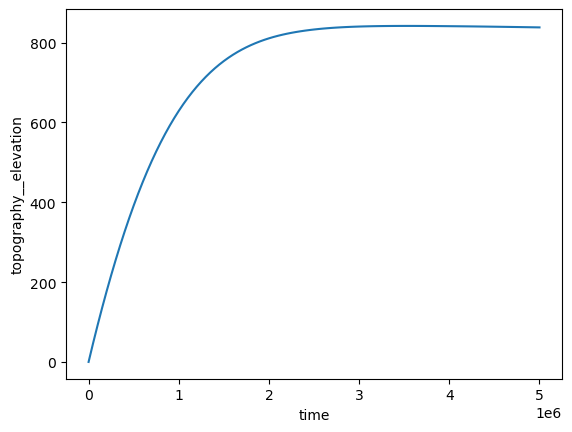

In [10]:
ds_out.topography__elevation.mean(('x','y')).plot();

Note that for small (fast) model, we can compbine these operations (running and plotting) in a single python line

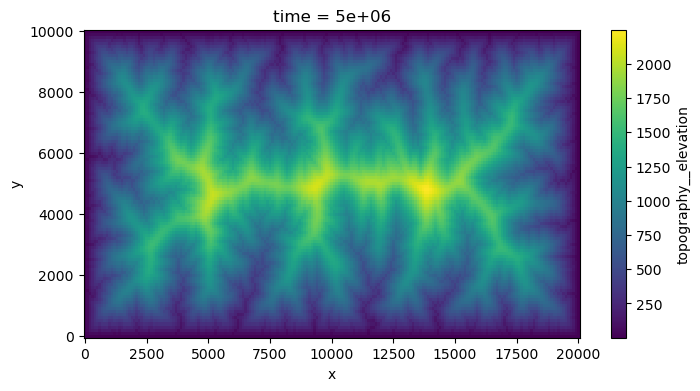

In [11]:
with basic_model:
    ds_in.xsimlab.run().topography__elevation.isel(time=-1).plot(size=4,aspect =2);

We can modify the input and output variables in the input dataset without redefining it. This is done with the methods `xsimlab.update_vars`

To illustrate this, we now perform a run with zero diffusivity to show the importance of the diffusion term in the equation and we ask for another output the `drainage__area`

In [16]:
with basic_model, xs.monitoring.ProgressBar():
    ds_out_noKd= (ds_in
                  .xsimlab.update_vars(input_vars ={'diffusion__diffusivity':0.0},
                                       output_vars ={'drainage__area': 'time',
                                                     'flow__basin': 'time'})
                  .xsimlab.run())

             0% | initialize 

We plot the resulting topography at the last time step and we see that the number of valleys (drainage density) is much higher in this model without hillslope processes

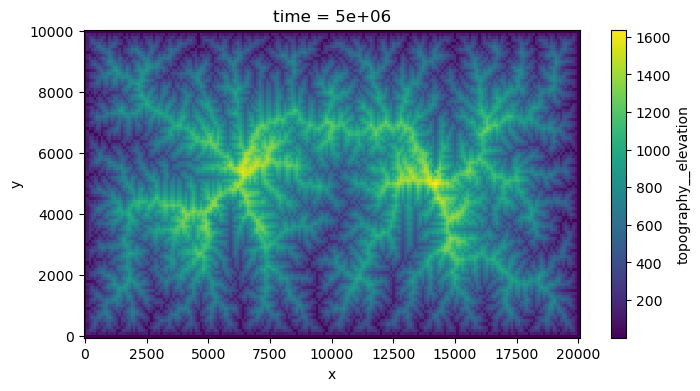

In [18]:
ds_out_noKd.topography__elevation.isel(time=-1).plot(size=4,aspect =2);

We can better see this if we plot the drainage__area and especially its logarithm

This allows us to illustrate how DataArrays can be used as numpy arrays

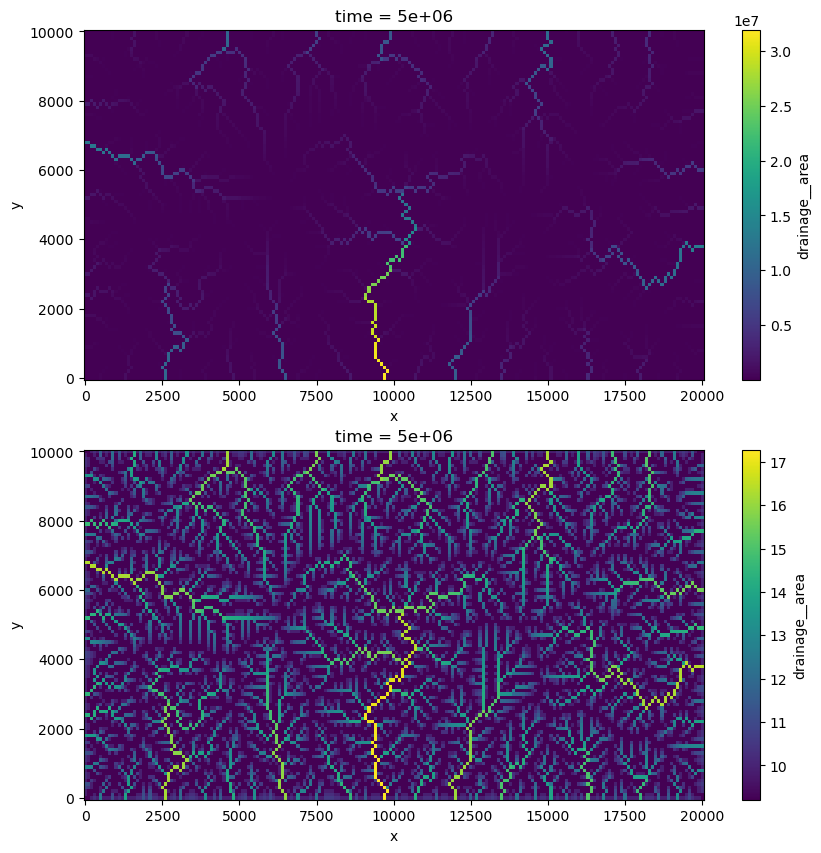

In [23]:
fig, ax = plt.subplots(nrows=2, figsize=(10,10))

ds_out_noKd.drainage__area.isel(time=-1).plot(ax=ax[0]);

np.log(ds_out_noKd.drainage__area).isel(time=-1).plot(ax=ax[1]);

We can also show the geometry of the drainage basins

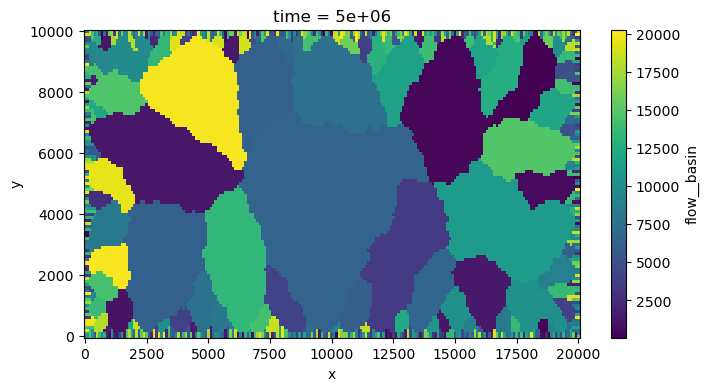

In [24]:
ds_out_noKd.flow__basin.isel(time=-1).plot(size=4,aspect =2);

Note that it is usually more efficient to request output form the model at a lower frequency than the frequency at which the model computes the solution. For this we introduce a main clock which we call `tstep` for the model and another clock we usually call `time` for the output

In [47]:
nout = 11
with basic_model, xs.monitoring.ProgressBar():
    ds_out_movie= (ds_in
                  .xsimlab.update_clocks(clocks={'tstep': np.linspace(0,tf,nstep),
                                                 'time': np.linspace(0,tf,nout)},
                                         master_clock='tstep')
                  .xsimlab.update_vars(output_vars ={'drainage__area': 'time'})
                  .xsimlab.run())

             0% | initialize 

We can use the model output to create a series `NetCDF` file that can be used to show the model results in 3D using `Paraview`

In [ ]:
ds_out_movie.x.attrs["units"]= "m"
ds_out_movie.y.attrs["units"]= "m"
ds_out_movie.time.attrs["units"]= "years"

(ds_out_movie.topography__elevation).to_netcdf('Topo.nc')
(ds_out_movie.drainage__area).to_netcdf('Area.nc')
